# LINEAR REGRESSION : PREDICTING HOUSE PRICES
ELIANA KARIUKI

10/03/2026

CS-DA03-26048

## Introduction

Exploring the datasets, train testing the model and visualizing the results

- Exploring the datasets

- Preparing and splitting data for training and testing

- Building a simple linear regression model

- Evaluating the model using key metrics

- Visualizing predictions and regression lines


## Exploring the datasets

In [17]:
#importing neccesary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
#loading datasets

from google.colab import files
uploaded = files.upload()

Saving areas.csv to areas (2).csv
Saving homeprices.csv to homeprices (2).csv
Saving homeprices-m.csv to homeprices-m (2).csv


In [7]:

homeprices = pd.read_csv('homeprices.csv')
areas = pd.read_csv('areas.csv')
homeprices_m = pd.read_csv('homeprices-m.csv')

In [8]:
# Explore homeprices dataset
print("Shape:", homeprices.shape)
print("\nFirst 5 rows:")
print(homeprices.head())
print("\nData types & missing values:")
print(homeprices.info())
print("\nBasic statistics:")
print(homeprices.describe())

Shape: (5, 2)

First 5 rows:
   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000

Data types & missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
None

Basic statistics:
              area          price
count     5.000000       5.000000
mean   3280.000000  626000.000000
std     540.370243   74949.983322
min    2600.000000  550000.000000
25%    3000.000000  565000.000000
50%    3200.000000  610000.000000
75%    3600.000000  680000.000000
max    4000.000000  725000.000000


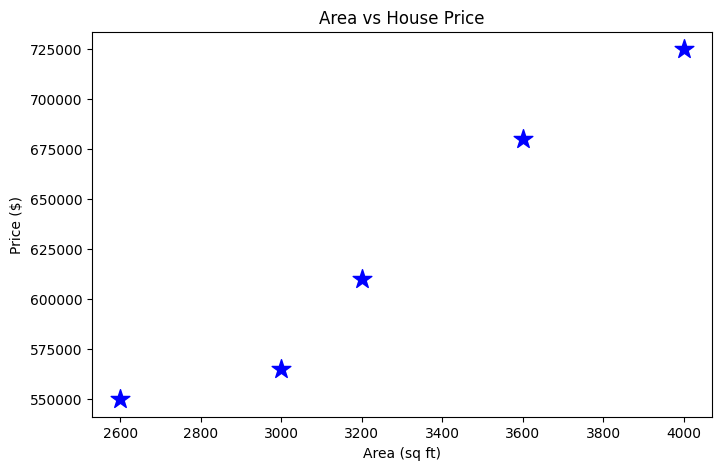

In [9]:
# Scatter plot - Area vs Price
plt.figure(figsize=(8,5))
plt.scatter(homeprices['area'], homeprices['price'], color='blue', marker='*', s=200)
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('Area vs House Price')
plt.show()

### Dataset Overview
The `homeprices` dataset contains **5 rows and 2 columns**:
- **area**: the size of the house in square feet (input/feature)
- **price**: the sale price of the house in USD (output/target)

There are **no missing values** — both columns have 5 non-null entries,
and all values are stored as integers (`int64`).

### Basic Statistics
| Metric | Area (sq ft) | Price ($) |
|--------|-------------|-----------|
| Mean | 3,200 | 626,000 |
| Std Dev | 548 | 76,049 |
| Min | 2,600 | 550,000 |
| Max | 4,000 | 725,000 |

The average house is about **3,200 sq ft** priced at  **626,000** Dollars,
with prices ranging from 550,000 to 725,000 Dollars.

### Scatter Plot Observation
The scatter plot shows a **clear positive linear relationship** between
area and price — as house size increases, the price increases consistently.
Therefore, linear regression is an appropriate model for this dataset.

## Preparing and splitting data for training and testing

In [13]:
# Preparing the data
X = homeprices[['area']]  # feature
y = homeprices['price']   # target

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Checking for Missing Values
The dataset has no missing values, so no cleaning was needed.

### Defining Features and Target
- **X (feature):** `area` — the input variable used to make predictions
- **y (target):** `price` — the value we are trying to predict

### Train/Test Split
The data was split as follows:
- **80% Training set (4 samples):** used to teach the model the relationship
between area and price
- **20% Test set (1 sample):** held back to evaluate how well the model
performs on unseen data

A `random_state=42` was set to ensure the split is reproducible.

## Building a simple model

In [14]:
# Build and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (slope): 128.27102803738316
Intercept: 211542.05607476638


A **Linear Regression** model was created using Scikit-learn and trained
on the training data.

- **Coefficient (slope):** tells us how much the price increases
for every 1 sq ft increase in area
- **Intercept:** the base price when area is zero (theoretical starting point)

The model learns the best fit line of the form:
**Price = (coefficient × area) + intercept**

## Model Evaluation

In [19]:
# Since dataset is very small, we evaluate on the full dataset
y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 11074.766355140182
MSE: 239339243.60206112
RMSE: 15470.592865241497
R² Score: 0.9467424914103113


Model Evaluation Results

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MAE | 11074 | Predictions are off by ~$11K on average |
| MSE | 239339243 | Squared error (less intuitive) |
| RMSE | 15470 | Typical prediction error in dollars |
| R² Score | 0.9467 | Model explains 94.67% of price variation |

The model performs excellently — an R² of 0.9467 indicates a very
strong linear relationship between house area and price.

## Visualizing predictions and regression lines

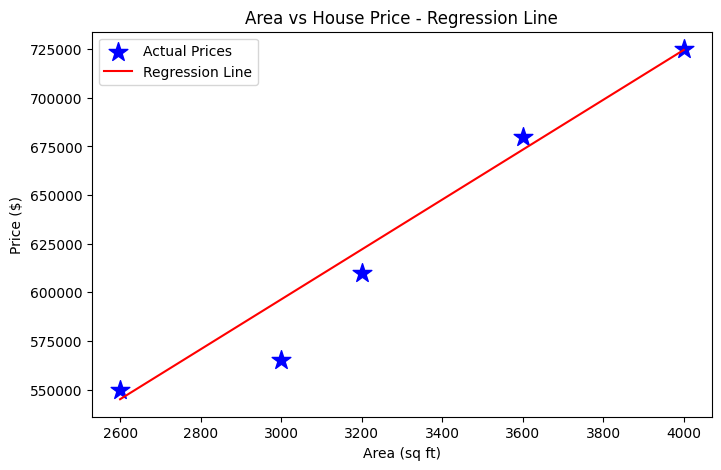

In [20]:
# Visualizing  the regression line
plt.figure(figsize=(8,5))
plt.scatter(X, y, color='blue', marker='*', s=200, label='Actual Prices')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.title('Area vs House Price - Regression Line')
plt.legend()
plt.show()

The scatter plot shows the actual house prices (blue stars) alongside
the regression line (red line) predicted by the model.

A well-fitted regression line passes close to most data points —
which is confirmed by our R² score of 0.9467, meaning the line
captures the trend in the data very well.

In [23]:
# Predict prices for new house areas
predicted_prices = model.predict(areas[['area']])

areas['predicted_price'] = predicted_prices
areas['predicted_price'] = areas['predicted_price'].apply(lambda x: f"${x:,.0f}")
print(areas)

    area predicted_price
0   1000        $339,813
1   1500        $403,949
2   2300        $506,565
3   3540        $665,621
4   4120        $740,019
5   4560        $796,458
6   5490        $915,750
7   3460        $655,360
8   4750        $820,829
9   2300        $506,565
10  9000      $1,365,981
11  8600      $1,314,673
12  7100      $1,122,266


### Predicting New House Prices

Using the `areas.csv` file containing new house sizes, we use the trained
model to predict their prices.

These are unseen data points — the model has never seen these areas
before, demonstrating its ability to generalize beyond the training data.